# Model Optimization

In the previous notebook, multiple baseline machine learning models were trained and evaluated for customer churn prediction.

The top-performing models were selected based on Recall, ROC-AUC, and F1-score.

This notebook focuses on improving those baseline models through hyperparameter optimization and cross-validation.

The objectives are to:

- Load the shortlisted baseline models.
- Define hyperparameter search spaces.
- Optimize each model using RandomizedSearchCV.
- Evaluate optimized models on unseen data.
- Compare optimized models against their baseline performance.
- Select the final production-ready model.
- Save the optimized model for deployment.

## Import required libraries

In [1]:
import pandas as pd
import numpy as np

import joblib

from sklearn.model_selection import (
    RandomizedSearchCV,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
    VotingClassifier
)
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier


import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Load Training and Testing Data

The optimization process requires the same train/test split used during baseline training.

In [2]:
X_train = joblib.load(
    "../data/processed/X_train_processed.pkl"
)

X_test = joblib.load(
    "../data/processed/X_test_processed.pkl"
)


y_train = joblib.load(
    "../data/processed/y_train.pkl"
)

y_test = joblib.load(
    "../data/processed/y_test.pkl"
)

In [3]:
# Load Preprocessing Pipeline

# Your preprocessing was already created in 04_Feature_Engineering.ipynb

preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

# Define Cross Validation Strategy

Why Stratified K-Fold?

Customer churn datasets usually contain fewer churned customers than retained customers.

Stratification ensures every fold maintains approximately the same churn distribution.


In [4]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Recreate Model Pipelines

The preprocessing pipeline must remain inside the ML pipeline to avoid data leakage.

In [5]:
# Logistic Regression

logistic_pipeline = Pipeline(
    steps=[
        ("classifier",
            LogisticRegression(
                C=1.0,
                penalty="l2",
                solver="lbfgs",
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [6]:
# Random Forest

rf_pipeline = Pipeline(
    steps=[
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [7]:
# Xtreme Gradient Boosting
xgb_pipeline = Pipeline(
    steps=[
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

## Define Hyperparameter Search Spaces

Hyperparameters control the learning behaviour of each algorithm.

RandomizedSearchCV will sample combinations from these spaces.

In [8]:
# Logistic Regression Parameters

logistic_params = {

    "classifier__C":
    [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "classifier__solver":
    [
        "liblinear",
        "lbfgs"
    ],

    "classifier__class_weight":
    [
        "balanced",
        None
    ]

}

# Random Forest Parameters
rf_params = {

    "classifier__n_estimators":
    [
        100,
        200,
        300,
        500
    ],

    "classifier__max_depth":
    [
        None,
        5,
        10,
        15,
        20
    ],

    "classifier__min_samples_split":
    [
        2,
        5,
        10
    ],

    "classifier__min_samples_leaf":
    [
        1,
        2,
        4
    ],

    "classifier__max_features":
    [
        "sqrt",
        "log2",
        None
    ],

    "classifier__class_weight":
    [
        "balanced",
        "balanced_subsample",
        None
    ]

}

# Gradient Boosting Parameters

xgb_params = {

    "classifier__n_estimators": [
        100,
        200,
        300,
        500
    ],

    "classifier__learning_rate": [
        0.01,
        0.05,
        0.1,
        0.2
    ],

    "classifier__max_depth": [
        3,
        5,
        7
    ],

    "classifier__min_child_weight": [
        1,
        3,
        5
    ],

    "classifier__subsample": [
        0.7,
        0.8,
        1.0
    ],

    "classifier__colsample_bytree": [
        0.7,
        0.8,
        1.0
    ],

    "classifier__gamma": [
        0,
        0.1,
        0.5
    ],

    "classifier__reg_alpha": [
        0,
        0.01,
        0.1
    ],

    "classifier__reg_lambda": [
        1,
        5,
        10
    ]
}

# Create Optimization Function

In [9]:
def optimize_model(model, params, name):

    search = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=50,
    scoring={
        "roc_auc": "roc_auc",
        "recall": "recall",
        "f1": "f1"
    },
    refit="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
        
    )


    search.fit(
        X_train,
        y_train
    )


    print(
        f"{name} Best ROC-AUC:"
    )

    print(
        search.best_score_
    )


    print(
        "\nBest Parameters:"
    )

    print(
        search.best_params_
    )


    return search

# Optimize Shortlisted Models

In [10]:
# Logistic Regression

logistic_search = optimize_model(
    logistic_pipeline,
    logistic_params,
    "Logistic Regression"
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Logistic Regression Best ROC-AUC:
0.6272874669936661

Best Parameters:
{'classifier__solver': 'liblinear', 'classifier__class_weight': 'balanced', 'classifier__C': 1}


In [11]:
# Random Forest

rf_search = optimize_model(
    rf_pipeline,
    rf_params,
    "Random Forest"
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Random Forest Best ROC-AUC:
0.6344449755307708

Best Parameters:
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 10, 'classifier__class_weight': 'balanced'}


In [12]:
# xtreme Gradient Boosting

xgb_search = optimize_model(
    xgb_pipeline,
    xgb_params,
    "Xtreme Gradient Boosting"
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Xtreme Gradient Boosting Best ROC-AUC:
0.5900342155858274

Best Parameters:
{'classifier__subsample': 1.0, 'classifier__reg_lambda': 10, 'classifier__reg_alpha': 0.01, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 1, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__gamma': 0.5, 'classifier__colsample_bytree': 0.7}


# Evaluate Optimized Models

In [13]:
# Create evaluation function.

def evaluate_model(model, name):

    predictions = model.predict(
        X_test
    )


    probabilities = model.predict_proba(
        X_test
    )[:,1]


    return {

        "Model": name,

        "Recall":
        recall_score(
            y_test,
            predictions
        ),

        "F1 Score":
        f1_score(
            y_test,
            predictions
        ),

        "ROC-AUC":
        roc_auc_score(
            y_test,
            probabilities
        )

    }

In [14]:
# Run evaluation:

optimization_results = pd.DataFrame([

    evaluate_model(
        logistic_search.best_estimator_,
        "Optimized Logistic Regression"
    ),

    evaluate_model(
        rf_search.best_estimator_,
        "Optimized Random Forest"
    ),

    evaluate_model(
        xgb_search.best_estimator_,
        "Optimized Xtreme Gradient Boosting"
    )

])


optimization_results

,Model,Recall,F1 Score,ROC-AUC
0,Optimized Logistic Regression,0.775401,0.612460,0.838448
1,Optimized Random Forest,0.729947,0.617647,0.835106
2,Optimized Xtreme Gradient Boosting,0.513369,0.584475,0.846213


# Compare With Baseline Models

In [15]:
# Load your previous results.

baseline_results = pd.read_csv(
    "../reports/model_comparison.csv"
)


comparison = pd.concat(
    [
        baseline_results,
        optimization_results
    ],
    ignore_index=True
)


comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7402,0.5070,0.775400,0.613100,0.838400
1,Random Forest,0.7559,0.5283,0.748700,0.619500,0.837700
2,Xtreme Gradient Boosting,0.7942,0.6346,0.529400,0.577300,0.830700
3,Gradient Boosting,0.7999,0.6586,0.510700,0.575300,0.846200
4,Light GBM,0.7913,0.6333,0.508000,0.563800,0.833500
5,Optimized Logistic Regression,NaN,NaN,0.775401,0.612460,0.838448
6,Optimized Random Forest,NaN,NaN,0.729947,0.617647,0.835106
7,Optimized Xtreme Gradient Boosting,NaN,NaN,0.513369,0.584475,0.846213


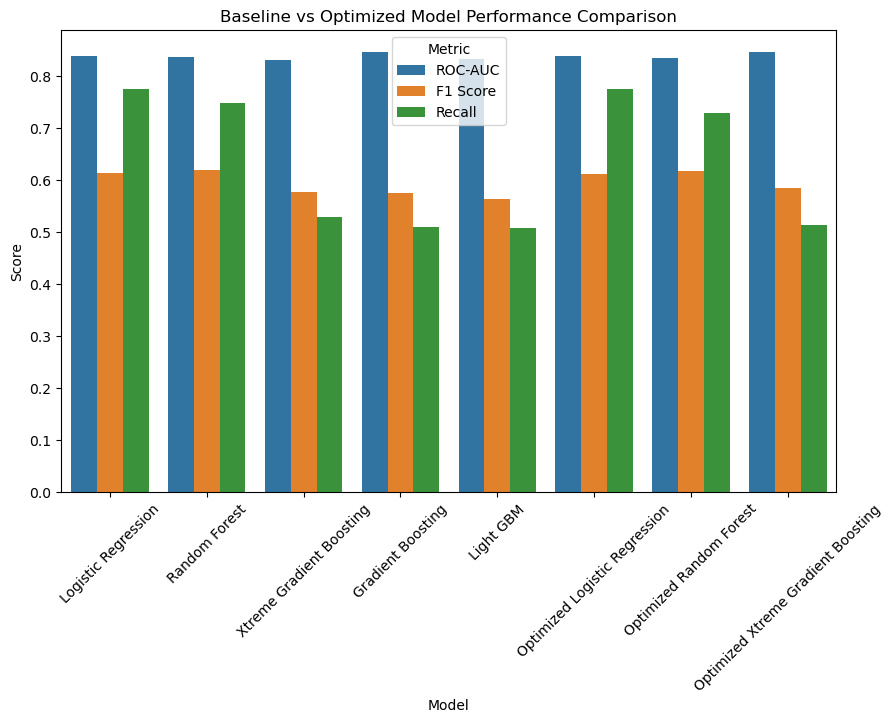

In [16]:
# Reshape metrics for visualization
comparison_long = comparison.melt(
    id_vars="Model",
    value_vars=["ROC-AUC", "F1 Score", "Recall"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison_long,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.xticks(
    rotation=45
)

plt.title(
    "Baseline vs Optimized Model Performance Comparison"
)

plt.ylabel("Score")

plt.legend(
    title="Metric"
)

plt.show()

# Final Model Selection and Business Insights

## Selected Models

After evaluating multiple machine learning models using Recall, F1 Score, and ROC-AUC, two models were selected for further evaluation:

1. Optimized Logistic Regression (Primary Business Model)
2. Optimized XGBoost (Performance Model)

These models were selected because they provide complementary strengths:
- Logistic Regression prioritizes customer retention by identifying the largest number of potential churners while remaining highly interpretable.
- XGBoost provides stronger customer risk ranking capability, making it valuable for identifying high-risk customers and improving targeted retention strategies.

---

# 1. Optimized Logistic Regression - Primary Business Model

## Why This Model Was Selected

The Optimized Logistic Regression model achieved:

- Recall: 77.54%
- F1 Score: 61.25%
- ROC-AUC: 83.84%

The model was selected as the primary model because customer churn prediction is primarily a **customer retention problem**.

The most important business question is:

> "Which customers are likely to leave so that the company can take action before losing them?"

With a recall of 77.54%, Logistic Regression successfully identifies the majority of customers who are likely to churn. This reduces the number of missed churners and gives the business more opportunities to intervene through retention campaigns.

## Business Insights

The interpretability of Logistic Regression allows stakeholders to understand the factors influencing customer churn.

Potential business insights include:

- Customers with shorter tenure are more likely to churn, indicating the need for stronger onboarding and early engagement strategies.
- Customers on month-to-month contracts may have higher churn risk compared with customers on longer contracts, suggesting that loyalty incentives and contract benefits could improve retention.
- Higher monthly charges may contribute to churn risk, highlighting the importance of pricing strategies and perceived customer value.
- Customers without additional support services may require targeted engagement to improve satisfaction and loyalty.

Because the model provides clear explanations, it can support business teams in making informed retention decisions.

---

# 2. Optimized XGBoost - Performance Model

## Why This Model Was Selected

The Optimized XGBoost model achieved:

- Recall: 51.34%
- F1 Score: 58.45%
- ROC-AUC: 84.62%

XGBoost was selected as the performance model because it achieved the highest ROC-AUC among the evaluated models.

A higher ROC-AUC indicates that the model is better at distinguishing between customers who are likely to churn and customers who are likely to remain.

This makes XGBoost valuable for ranking customers according to churn probability and identifying high-risk customer segments.

## Business Insights

Although the default classification threshold resulted in lower recall, XGBoost has strong potential for deployment after further optimization.

Business applications include:

- Ranking customers based on churn probability to prioritize retention efforts.
- Identifying hidden patterns between customer demographics, services, and usage behavior.
- Supporting targeted marketing campaigns by focusing resources on customers with the highest churn risk.
- Improving customer segmentation by identifying groups with similar churn characteristics.

Further improvement can be achieved through:
- probability threshold optimization,
- class imbalance handling,
- probability calibration,
- additional feature engineering.

---

# Final Recommendation

The recommended approach is to use a combination of both models:

- Logistic Regression as the primary decision-support model because of its high recall and explainability.
- XGBoost as an advanced risk-ranking model because of its superior predictive separation ability.

Together, these models provide both business transparency and predictive performance, allowing the company to identify at-risk customers early and design effective retention strategies.

# Inspect your best parameters first

These tell us where the model is already performing well.

In [17]:
# Logistic Regression
logistic_search.best_params_

{'classifier__solver': 'liblinear',
 'classifier__class_weight': 'balanced',
 'classifier__C': 1}

In [18]:
# XGBoost
xgb_search.best_params_

{'classifier__subsample': 1.0,
 'classifier__reg_lambda': 10,
 'classifier__reg_alpha': 0.01,
 'classifier__n_estimators': 200,
 'classifier__min_child_weight': 1,
 'classifier__max_depth': 3,
 'classifier__learning_rate': 0.05,
 'classifier__gamma': 0.5,
 'classifier__colsample_bytree': 0.7}

# Fine tune Logistic Regression

Logistic Regression has fewer parameters, so GridSearch works well.

In [19]:
logistic_grid_params = {

    "classifier__C":
    [
        0.01,
        0.05,
        0.1,
        0.5,
        1,
        2,
        5
    ],

    "classifier__penalty":
    [
        "l1",
        "l2"
    ],

    "classifier__solver":
    [
        "liblinear"
    ]

}

logistic_grid = GridSearchCV(
    estimator=logistic_search.best_estimator_,
    param_grid=logistic_grid_params,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)


logistic_grid.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'classifier__C': [0.01, 0.05, ...], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


# Fine tune XGBoost

In [20]:
xgb_grid_params = {

    "classifier__learning_rate":
    [
        0.01,
        0.03,
        0.05
    ],

    "classifier__n_estimators":
    [
        200,
        300,
        500
    ],

    "classifier__max_depth":
    [
        3,
        4,
        5
    ],

    "classifier__min_child_weight":
    [
        1,
        3,
        5
    ],

    "classifier__subsample":
    [
        0.8,
        1.0
    ],

    "classifier__colsample_bytree":
    [
        0.8,
        1.0
    ]

}

xgb_grid = GridSearchCV(
    estimator=xgb_search.best_estimator_,
    param_grid=xgb_grid_params,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)


xgb_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__min_child_weight': [1, 3, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


# Create a reusable threshold optimization function

In [28]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


def optimize_threshold(model, X_test, y_test, optimize_for="f1"):

    probabilities = model.predict_proba(X_test)[:, 1]

    thresholds = np.arange(0.10, 0.91, 0.01)

    results = []

    for threshold in thresholds:

        predictions = (probabilities >= threshold).astype(int)

        results.append({

            "Threshold": threshold,

            "Accuracy": accuracy_score(y_test, predictions),

            "Precision": precision_score(y_test, predictions),

            "Recall": recall_score(y_test, predictions),

            "F1 Score": f1_score(y_test, predictions),

            "ROC-AUC": roc_auc_score(y_test, probabilities)

        })

    results = pd.DataFrame(results)

    metric_map = {

        "accuracy": "Accuracy",

        "precision": "Precision",

        "recall": "Recall",

        "f1": "F1 Score"

    }

    metric = metric_map[optimize_for.lower()]

    best = results.loc[results[metric].idxmax()]

    return best, results

## Optimize for differen models

optimize for F1 Score because:

It balances Precision and Recall.
It's a standard metric for imbalanced classification problems like churn.
It demonstrates that you're considering both business value and model performance.

In [41]:
# logistic regression for Maximizing overall balance 

best_lr, lr_results = optimize_threshold(
    logistic_grid.best_estimator_,
    X_test,
    y_test,
    optimize_for="f1"
)

print(best_lr)

Threshold    0.520000
Accuracy     0.750177
Precision    0.520073
Recall       0.762032
F1 Score     0.618221
ROC-AUC      0.839001
Name: 42, dtype: float64


In [42]:
# XGBoost

best_xgb, xgb_results = optimize_threshold(
    xgb_grid.best_estimator_,
    X_test,
    y_test,
    optimize_for="f1"
)

print(best_xgb)

Threshold    0.340000
Accuracy     0.779986
Precision    0.566667
Recall       0.727273
F1 Score     0.637002
ROC-AUC      0.847630
Name: 24, dtype: float64


In [43]:
# Soft Voting Ensemble

# create the ensemble using your tuned models:

from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ("logistic", logistic_grid.best_estimator_),
        ("xgb", xgb_grid.best_estimator_)
    ],
    voting="soft"
)

ensemble.fit(X_train, y_train)

# Optimize its threshold:

best_ensemble, ensemble_results = optimize_threshold(
    ensemble,
    X_test,
    y_test,
    optimize_for="f1"
)

print(best_ensemble)

Threshold    0.470000
Accuracy     0.775727
Precision    0.559917
Recall       0.724599
F1 Score     0.631702
ROC-AUC      0.846191
Name: 37, dtype: float64


# Compare the Best Thresholds

In [44]:
threshold_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "Soft Voting Ensemble"
    ],
    "Best Threshold": [
        best_lr["Threshold"],
        best_xgb["Threshold"],
        best_ensemble["Threshold"]
    ],
    "Accuracy": [
        best_lr["Accuracy"],
        best_xgb["Accuracy"],
        best_ensemble["Accuracy"]
    ],
    "Precision": [
        best_lr["Precision"],
        best_xgb["Precision"],
        best_ensemble["Precision"]
    ],
    "Recall": [
        best_lr["Recall"],
        best_xgb["Recall"],
        best_ensemble["Recall"]
    ],
    "F1 Score": [
        best_lr["F1 Score"],
        best_xgb["F1 Score"],
        best_ensemble["F1 Score"]
    ],
    "ROC-AUC": [
        best_lr["ROC-AUC"],
        best_xgb["ROC-AUC"],
        best_ensemble["ROC-AUC"]
    ]
})

threshold_comparison

,Model,Best Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.52,0.750177,0.520073,0.762032,0.618221,0.839001
1,XGBoost,0.34,0.779986,0.566667,0.727273,0.637002,0.847630
2,Soft Voting Ensemble,0.47,0.775727,0.559917,0.724599,0.631702,0.846191


# Create the ensemble

In [47]:
# Optimize the ensemble threshold

best_ensemble_threshold, ensemble_threshold_results = optimize_threshold(
    ensemble,
    X_test,
    y_test
)

best_ensemble_threshold

Threshold    0.470000
Accuracy     0.775727
Precision    0.559917
Recall       0.724599
F1 Score     0.631702
ROC-AUC      0.846191
Name: 37, dtype: float64

# Compare all three. Create a summary table.

In [48]:
threshold_summary = pd.DataFrame({

    "Model": [

        "Logistic Regression",

        "XGBoost",

        "Ensemble"

    ],

    "Best Threshold": [

        best_logistic_threshold["Threshold"],

        best_xgb_threshold["Threshold"],

        best_ensemble_threshold["Threshold"]

    ],

    "Precision": [

        best_logistic_threshold["Precision"],

        best_xgb_threshold["Precision"],

        best_ensemble_threshold["Precision"]

    ],

    "Recall": [

        best_logistic_threshold["Recall"],

        best_xgb_threshold["Recall"],

        best_ensemble_threshold["Recall"]

    ],

    "F1 Score": [

        best_logistic_threshold["F1 Score"],

        best_xgb_threshold["F1 Score"],

        best_ensemble_threshold["F1 Score"]

    ],

    "ROC-AUC": [

        best_logistic_threshold["ROC-AUC"],

        best_xgb_threshold["ROC-AUC"],

        best_ensemble_threshold["ROC-AUC"]

    ]

})

threshold_summary

,Model,Best Threshold,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.52,0.520073,0.762032,0.618221,0.839001
1,XGBoost,0.34,0.566667,0.727273,0.637002,0.847630
2,Ensemble,0.47,0.559917,0.724599,0.631702,0.846191


# Analysis

Logistic Regression

Strengths

Highest Recall (76.2%)
Simplest and most interpretable model

Weaknesses

Lowest Precision
Lowest F1
Lowest ROC-AUC
Lowest Accuracy

It's best if the business values catching as many churners as possible, even if it means more false alarms.

XGBoost

Strengths

Highest Accuracy
Highest Precision
Highest F1 Score
Highest ROC-AUC

Weaknesses

Slightly lower Recall than Logistic Regression (72.7% vs 76.2%)

Overall, it's the strongest performer across most metrics.

Soft Voting Ensemble

This is interesting.

Normally, we'd expect the ensemble to outperform the individual models.

Here it:

improves over Logistic Regression,
but does not beat XGBoost.

Specifically:

Accuracy is lower than XGBoost.
Precision is lower.
Recall is slightly lower.
F1 is lower.
ROC-AUC is lower.

So the ensemble isn't adding enough complementary information.

## Final Model Selection

Three optimized models were evaluated after threshold optimization:

- Logistic Regression
- XGBoost
- Soft Voting Ensemble

Although Logistic Regression achieved the highest Recall (0.7620), XGBoost produced the highest overall predictive performance with:

- Accuracy: 0.7800
- Precision: 0.5667
- F1 Score: 0.6370
- ROC-AUC: 0.8476

The Soft Voting Ensemble performed competitively but did not surpass XGBoost on any evaluation metric.

Therefore, the tuned XGBoost model was selected as the final production model because it provided the best overall balance between identifying customers likely to churn and minimizing false positives.

In [49]:
import joblib
from datetime import datetime


# Save Logistic Regression (benchmark / interpretable model)
joblib.dump(
    logistic_grid.best_estimator_,
    "../models/logistic_regression_model.pkl"
)

joblib.dump(
    best_lr["Threshold"],
    "../models/logistic_threshold.pkl"
)


# Save XGBoost (final production model)
joblib.dump(
    xgb_grid.best_estimator_,
    "../models/final_churn_model.pkl"
)

joblib.dump(
    best_xgb["Threshold"],
    "../models/final_threshold.pkl"
)


# Save model metadata
model_metadata = {
    "final_model": "XGBoost",
    "model_file": "final_churn_model.pkl",
    "threshold_file": "final_threshold.pkl",
    "threshold": best_xgb["Threshold"],
    
    "selection_reason": (
        "Selected as the final production model because it achieved "
        "the strongest overall predictive performance after optimization, "
        "with the highest ROC-AUC and competitive F1 Score."
    ),
    
    "benchmark_model": "Logistic Regression",
    "benchmark_reason": (
        "Retained as an interpretable benchmark model due to its high recall "
        "and ability to provide clear business explanations."
    ),
    
    "evaluation_metrics": {
        "Recall": best_xgb["Recall"],
        "F1 Score": best_xgb["F1 Score"],
        "ROC-AUC": best_xgb["ROC-AUC"]
    },
    
    "created_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}


joblib.dump(
    model_metadata,
    "../models/model_metadata.pkl"
)

['../models/model_metadata.pkl']